# SGD

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
DATASET_PATH = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\processed\dataset_augmented.npz"
OUTPUT_DIR   = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results"

In [3]:
PCA_COMPONENTS = 150
RANDOM_SEED    = 42
 
# SGD parameters to try sequentially
# Script will test all combinations and report the best
SGD_PARAMS = [
    {'loss': 'hinge',         'alpha': 0.0001},  # approximates linear SVM
    {'loss': 'hinge',         'alpha': 0.001},
    {'loss': 'modified_huber','alpha': 0.0001},  # smoother loss, often better
    {'loss': 'modified_huber','alpha': 0.001},
]

In [4]:
def load_data(path):
    """Load the dataset."""
    print("Loading dataset...")
    data = np.load(path)
 
    X_train = np.concatenate([data['X_train'], data['X_val']])
    y_train = np.concatenate([data['y_train'], data['y_val']])
    X_test  = data['X_test']
    y_test  = data['y_test']
 
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples:     {len(X_test)}")
    print(f"  Features:         {X_train.shape[1]:,}\n")
 
    return X_train, X_test, y_train, y_test

In [5]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plot and save a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'PSA {i}' for i in range(1, 11)],
        yticklabels=[f'PSA {i}' for i in range(1, 11)]
    )
    plt.title(title)
    plt.ylabel('True Grade')
    plt.xlabel('Predicted Grade')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"  Confusion matrix saved to: {save_path}")

In [6]:
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
 
    X_train, X_test, y_train, y_test = load_data(DATASET_PATH)
 
    # Apply PCA once upfront so we don't repeat it for every SGD run
    print(f"Applying PCA ({PCA_COMPONENTS} components)...")
    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    print(f"  Reduced features: {X_train_pca.shape[1]}\n")
 
    # SGD works best with scaled data
    print("Scaling data...")
    scaler      = StandardScaler()
    X_train_pca = scaler.fit_transform(X_train_pca)
    X_test_pca  = scaler.transform(X_test_pca)
    print("  Done\n")
 
    results = []
 
    for i, params in enumerate(SGD_PARAMS, 1):
        print(f"{'='*50}")
        print(f"[{i}/{len(SGD_PARAMS)}] loss={params['loss']}, alpha={params['alpha']}")
        print(f"{'='*50}")
 
        model = SGDClassifier(
            loss=params['loss'],
            alpha=params['alpha'],
            max_iter=1000,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
 
        model.fit(X_train_pca, y_train)
        preds      = model.predict(X_test_pca)
        accuracy   = accuracy_score(y_test, preds)
        within_one = np.mean(np.abs(y_test - preds) <= 1)
 
        print(f"  Exact accuracy:  {accuracy*100:.1f}%")
        print(f"  Within 1 grade:  {within_one*100:.1f}%\n")
 
        results.append({
            'loss':       params['loss'],
            'alpha':      params['alpha'],
            'accuracy':   accuracy,
            'within_one': within_one,
            'preds':      preds
        })
 
    # Find best result
    best = max(results, key=lambda x: x['accuracy'])
 
    print(f"\n{'='*50}")
    print(f"Best combination:")
    print(f"  loss={best['loss']}, alpha={best['alpha']}")
    print(f"  Exact accuracy:  {best['accuracy']*100:.1f}%  (SVM baseline was 52.9%)")
    print(f"  Within 1 grade:  {best['within_one']*100:.1f}%  (SVM baseline was 75.0%)")
    print(f"{'='*50}")
 
    print(f"\nClassification Report (best model):")
    print(classification_report(
        y_test, best['preds'],
        target_names=[f'PSA {i}' for i in range(1, 11)],
        zero_division=0
    ))
 
    # Confusion matrix for best model
    plot_confusion_matrix(
        y_test, best['preds'],
        f"PCA+SGD Best Model (loss={best['loss']}, alpha={best['alpha']})",
        "sgd_best_confusion.png"
    )
 
    # Save results
    results_path = os.path.join(OUTPUT_DIR, 'sgd_results.txt')
    with open(results_path, 'w', encoding='utf-8') as f:
        f.write(f"PCA + SGD Classifier Results\n{'='*50}\n\n")
        f.write(f"PCA Components: {PCA_COMPONENTS}\n\n")
        f.write(f"{'Loss':<20} {'Alpha':<12} {'Exact Acc':<12} {'Within 1':<12}\n")
        f.write(f"{'-'*56}\n")
        for r in results:
            f.write(
                f"{r['loss']:<20} {r['alpha']:<12} "
                f"{r['accuracy']*100:<12.1f} {r['within_one']*100:<12.1f}\n"
            )
        f.write(f"\nBest: loss={best['loss']}, alpha={best['alpha']}\n")
        f.write(f"  Exact accuracy:  {best['accuracy']*100:.1f}%\n")
        f.write(f"  Within 1 grade:  {best['within_one']*100:.1f}%\n")
        f.write(f"\nClassification Report:\n")
        f.write(classification_report(
            y_test, best['preds'],
            target_names=[f'PSA {i}' for i in range(1, 11)],
            zero_division=0
        ))
 
    print(f"Results saved to: {results_path}")
    print("\nAll done!")

Loading dataset...
  Training samples: 27855
  Test samples:     1145
  Features:         150,528

Applying PCA (150 components)...
  Reduced features: 150

Scaling data...
  Done

[1/4] loss=hinge, alpha=0.0001
  Exact accuracy:  27.2%
  Within 1 grade:  61.0%

[2/4] loss=hinge, alpha=0.001
  Exact accuracy:  29.3%
  Within 1 grade:  60.8%

[3/4] loss=modified_huber, alpha=0.0001


C:\Users\wldky\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


  Exact accuracy:  29.9%
  Within 1 grade:  62.7%

[4/4] loss=modified_huber, alpha=0.001
  Exact accuracy:  32.7%
  Within 1 grade:  67.2%


Best combination:
  loss=modified_huber, alpha=0.001
  Exact accuracy:  32.7%  (SVM baseline was 52.9%)
  Within 1 grade:  67.2%  (SVM baseline was 75.0%)

Classification Report (best model):
              precision    recall  f1-score   support

       PSA 1       0.00      0.00      0.00         7
       PSA 2       1.00      0.50      0.67         4
       PSA 3       0.14      0.02      0.03        56
       PSA 4       0.33      0.07      0.11        61
       PSA 5       0.24      0.12      0.16       131
       PSA 6       0.19      0.08      0.11        73
       PSA 7       0.35      0.57      0.43       264
       PSA 8       0.30      0.36      0.32       284
       PSA 9       0.37      0.41      0.39       218
      PSA 10       0.36      0.11      0.16        47

    accuracy                           0.33      1145
   macro avg    

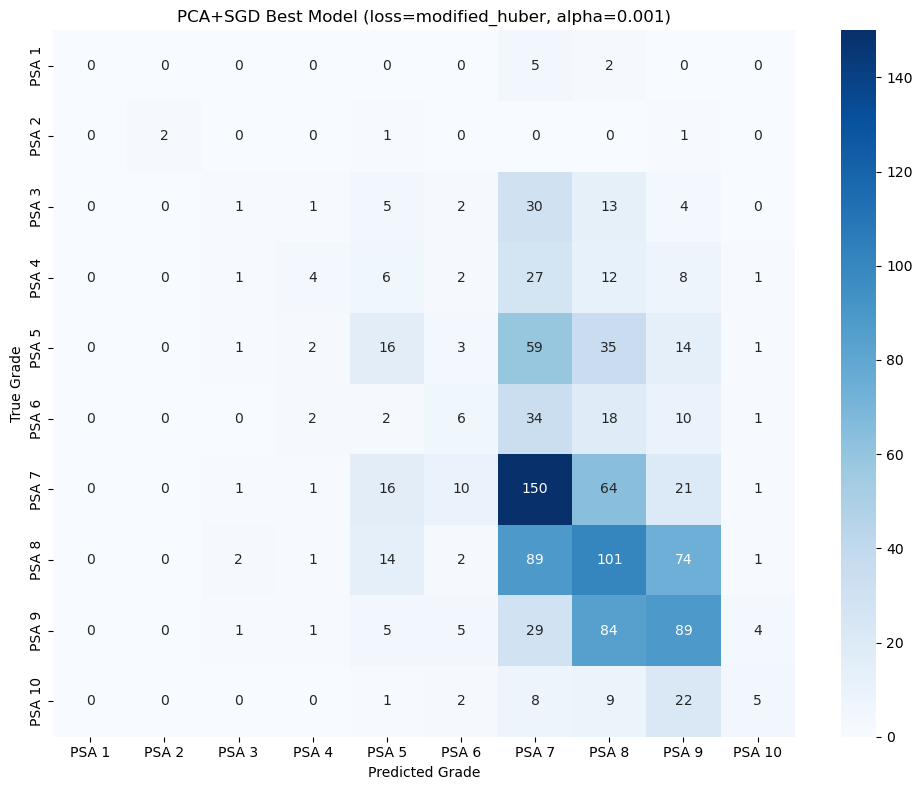

  Confusion matrix saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\sgd_best_confusion.png
Results saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\results\sgd_results.txt

All done!


In [7]:
main()